In [13]:
from typing import Optional
import graphviz
import uuid
import math

class Operator():
    def __init__(self,operator:str):
        self.id=uuid.uuid4().hex
        self.label=operator

class Value():
    def __init__(self,data,children=()
                          ,label:Optional[str]=None
                          ,operator:Optional[str]=None):
        self.id=uuid.uuid4().hex
        self.data=data
        self.label=label
        self.grad=0
        self.children=set(children)
        self.operator=None if operator is None else Operator(operator)
        self._backward=lambda:None
    
    def __add__(self,other):
        other=other if isinstance(other,Value) else Value(other)  
        out=Value(self.data+other.data,children=(self,other),operator="+")
        def _backward():
            self.grad+=1.0*out.grad
            other.grad+=1.0*out.grad
        
        out._backward=_backward
        return out
    
    def __rmul__(self,other):
        return self*other
    
    def __sub__(self,other):   #a-b
        return self+(-other)
    
    def __rsub__(self,other): #b-a
        return  (-self)+other
    
    def __neg__(self):
        return self * -1
    
    def __pow__(self,other):
        other=other if isinstance(other,Value) else Value(other)
        out=Value(self.data**other.data,children=(self,),operator=f"**{other.data}")

        def _backward():
            self.grad+=other.data*(self.data**(other.data-1))*out.grad
        out._backward=_backward
        return out
    
    def __mul__(self,other):
        other= other if isinstance(other,Value) else Value(other)
        out=Value(self.data*other.data,children=(self,other),operator='*')
        def _backward():
            self.grad+=other.data*out.grad
            other.grad+=self.data*out.grad
        out._backward=_backward
        return out
    
    def __truediv__(self,other):  # a/b
        return self * other ** -1
    
    def __rtruediv__(self,other): #b/a
        return  self ** -1 * other
    
    def exp(self):
        x=self.data
        out=Value(math.exp(x),children=(self,),operator=f"e**{self.data}")

        def _backward():
            self.grad+=out.data*out.grad
        out._backward=_backward
        return out

    def backward(self):

        # self._backward()
        # def backwardchild(node):
        #     if node.children is not None:
        #         for child in node.children:
        #             child._backward()
        #             backwardchild(child)
        # backwardchild(self)
        topo=[]
        visited=set()
        def build(v):
            if v not in visited:
                visited.add(v)
                for child in v.children:
                    build(child)
                topo.append(v)
        
        build(self)
        self.grad=1.0
        for node in reversed(topo):
            node._backward()

    
    def __repr__(self):
        return f"Value(data={self.data},grad={self.grad})"
    
    def printGraph(self):
        dot=graphviz.Digraph("test",node_attr={'shape': 'record'})

        dot.node(self.id,f'<f0> {self.label} data:{self.data}|<f1> grad:{self.grad}')
        visited=set()
        visited.add(self)
        def printNode(node):
            op=node.operator
            if op is not None:
                dot.node(op.id,op.label)
                dot.edge(op.id,node.id)
                for child in node.children:
                    if child not in visited:
                        visited.add(child)
                        dot.node(child.id,f'<f0> {child.label} data:{child.data}|<f1> grad:{child.grad}')
                        dot.edge(child.id,op.id)
                        printNode(child)
        
        printNode(self)

        return dot




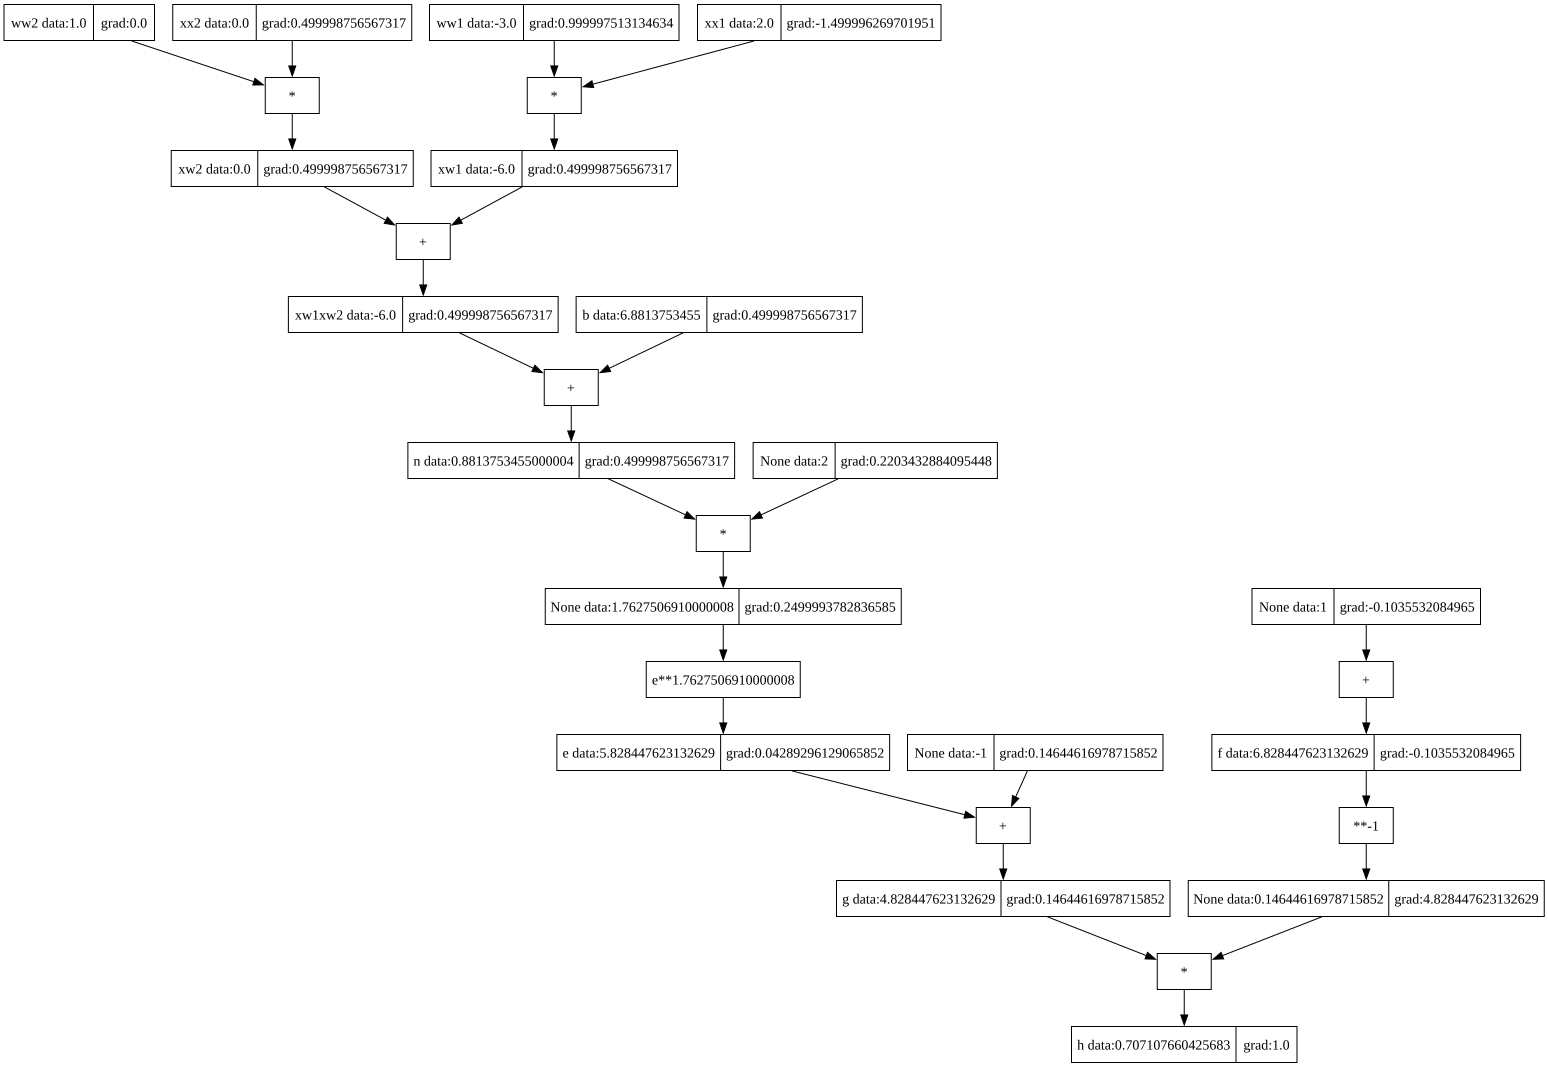

In [14]:
xx1=Value(2.0,label='xx1')
xx2=Value(0.0,label='xx2')
ww1=Value(-3.0,label='ww1')
ww2=Value(1.0,label='ww2')
b=Value(6.8813753455,label='b')
xw1=xx1*ww1;xw1.label='xw1'
xw2=xx2*ww2;xw2.label='xw2'

xw1xw2=xw1+xw2;xw1xw2.label='xw1xw2'  
n=xw1xw2+b;n.label='n'
# n.backward()
# n.printGraph()
e=(2*n).exp();e.label='e'
# e.backward()
# e.printGraph()
f=(e+1);f.label='f'
g=(e-1);g.label='g'
h=g/f;h.label='h'
h.backward()
h.printGraph()

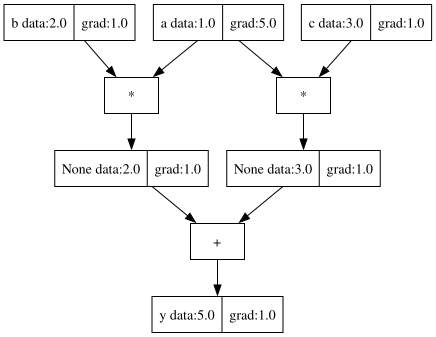

In [112]:
a=Value(1.0,label='a')
b=Value(2.0,label='b')
c=Value(3.0,label='c')

y=a*b+a*c;y.label='y'
y.backward()
y.printGraph()

In [90]:
import torch

x1=torch.tensor(2.0,requires_grad=True)
x2=torch.tensor(0.0,requires_grad=True)
w1=torch.tensor(-3.0,requires_grad=True)
w2=torch.tensor(1.0,requires_grad=True)
b=torch.tensor(6.8813753455,requires_grad=True) 
r=x1*w1+x2*w2
r1=r+b
#r.backward()
s=torch.exp(2*r1)
j1=s-1;
j2=s+1;
#s=torch.tanh(r)
j22=j2**-1
h1=j1*j22
#h1.backward()
gradj1,gradj2,gradr1,gradr=torch.autograd.grad(h1,[j1,j22,r1,r])
print(gradj1,gradj2,gradr1,gradr,r.data)
#h1.backward()
print(h1)
print(f"x1:{x1.grad},x2:{x2.grad},w1:{w1.grad},w2:{w2.grad}")

tensor(0.1464) tensor(4.8284) tensor(0.5000) tensor(0.5000) tensor(-6.)
tensor(0.7071, grad_fn=<MulBackward0>)
x1:None,x2:None,w1:None,w2:None
